# Agent-Based Model for Comparative Aggregation Rules Analysis

## Simulation Overview

This study employs an agent-based model to investigate how different aggregation rules perform in collective decision-making scenarios. The model simulates a group of agents who must identify the objectively best option from a set of alternatives based on noisy observations.

### Core Setup

- **Agents**: A group of decision-makers who observe options and provide graded assessments
- **Options**: Multiple alternatives to evaluate, with one objectively best option
- **Objective Grades**: Each option has a fixed, true grade representing its objective quality. These grades are determined by the profile type and remain constant throughout the simulation. The agents try to identify the option with the highest objective grade. 
- **Competence**: Each agent has a probability of being "competent" (providing relatively accurate observations of all option grades) versus "incompetent" (providing random or highly noisy observations of all option grades)
- **Noise Model**: 
  - Competent agents observe each option's true grade with bounded noise (±1.5)
  - Incompetent agents provide random grades or grades with large noise (±2.5)
  - Competence applies uniformly to all options - competent agents see all grades with similar accuracy

### Research Questions

This study addresses two questions:

1. **Best Option Identification**: How effectively can different aggregation rules identify the objectively best option?
2. **Ranking Adequacy**: How well do different aggregation rules produce rankings that correspond to the true preference ordering of options?

These questions are evaluated using two complementary metrics:
- **True Positive Rate (TP%)**: Percentage of times the aggregation rule correctly identifies the best option
- **Normalized Kendall-Tau Distance**: Measures how closely the aggregated ranking matches the objective ranking (0 = perfect match, 1 = completely inverted)

## Comparison Types (Aggregation Rules)

### Majority Judgment (MJ)

Majority Judgment uses a sophisticated multi-step comparison process:

1. **Median Comparison**: Compare the median grades of the two options. The option with the higher median wins.

2. **Interval Expansion with Domination and Concision Checks**: 
   - Expand outward from the median to include grades above (R-list) and below (L-list) the median
   - For each level k, compare the k-th highest grade above the median (R_k) and the k-th lowest grade below the median (L_k) for both options
   - **At each level**, perform the following checks in order:
     - **Domination Check**: If R_k_A > R_k_B and L_k_A ≤ L_k_B, Option A wins (dominance on the right). If R_k_A ≤ R_k_B and L_k_A > L_k_B, Option B wins (dominance on the left). If both show dominance for the same option, that option wins.
     - **Concision Check**: If no domination is found, check which option has more concise grades at this level. The option with grades closer to the median (less extreme) is preferred, as it shows more consensus.
   - Move to the next level (k+1) if no winner is determined at level k

### Risk Embracing (RE)

RE follows the same initial steps as MJ (median comparison and domination check), but then focuses specifically on the right tail (grades above the median) to break ties. This makes RE more sensitive to options with consistently high grades.

### Risk Averse (RAV)

RAV follows the same initial steps as MJ, but then focuses specifically on the left tail (grades below the median) to break ties. This makes RAV more conservative, preferring options with fewer low grades.

### Radical Variants

**Radical Risk Embracing (RE_RAD)**: Skips the domination check and directly compares right tails. More aggressive in selecting options with high grades.

**Radical Risk Averse (RAV_RAD)**: Skips the domination check and directly compares left tails. More conservative in avoiding options with low grades.

### Simple Majority Rule

**Strict Majority Rule (SMR)**: Counts how many agents give each option the highest possible grade. The option with the most "first-place" votes wins.

## Profile Types

The study examines four distinct profile types that represent different challenge scenarios:

### Centered Profile
- **Structure**: Grades clustered around the middle range (e.g., [2, 3, 3, 3, 4, 3, 3])
- **Challenge**: The best option has only a minimal advantage (gap of 1) over similar-valued alternatives
- **Difficulty**: High - agents must distinguish small differences in a dense grade distribution

### Upper End Profile  
- **Structure**: Grades concentrated in the upper range (e.g., [3, 4, 4, 4, 5, 4, 4])
- **Challenge**: The best option (grade 5) is only slightly better than many alternatives (grade 4)
- **Difficulty**: High - noise can easily obscure the distinction between top-tier options

### Lower End Profile
- **Structure**: Grades concentrated in the lower range (e.g., [1, 1, 2, 2, 3, 2, 2])  
- **Challenge**: The best option (grade 3) has minimal advantage over similar alternatives (grade 2)
- **Difficulty**: Moderate-High - similar to centered but with lower overall grade values

### Free Profile
- **Structure**: Randomly generated grades with guaranteed unique maximum and minimum gap of 1
- **Challenge**: Variable difficulty depending on the random grade distribution
- **Difficulty**: Moderate - provides a baseline for comparison with structured profiles

## Key Features

- **7 Options**: Each decision scenario involves 7 alternatives
- **11 Agents**: A moderate-sized group for collective decision-making
- **4 Competence Levels**: Testing performance across [0.3, 0.5, 0.7, 0.9]
- **Guaranteed Unique Best**: All profiles ensure exactly one option has the highest objective grade
- **Realistic Noise**: Bounded noise models that reflect real-world observation uncertainty

This experimental design allows for systematic comparison of how different aggregation principles perform under varying conditions of information quality and option similarity.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum
from functools import cmp_to_key

# ─────────────────────────────────────────────────────────────────────────────
# 1. GRADES & SIMULATION (FIXED & IMPROVED)
# ─────────────────────────────────────────────────────────────────────────────
class Grade(IntEnum):
    P = 0; F = 1; G = 2; A = 3; VG = 4; E = 5; S = 6

def majority_grade(grades: np.ndarray) -> int:
    """Returns the median grade (Majority Grade)."""
    sorted_g = np.sort(grades)[::-1]
    return sorted_g[(len(sorted_g) - 1) // 2]

def dominates(sorted_a: np.ndarray, sorted_b: np.ndarray) -> bool:
    """Strict Domination: a dominates b if all a_i >= b_i and at least one a_i > b_i."""
    return np.all(sorted_a >= sorted_b) and np.any(sorted_a > sorted_b)

def get_interval_scores(grades: np.ndarray, median: int):
    """
    Extracts grades strictly above and below the median.
    R_list: grades > median, sorted descending (R1, R2, ...)
    L_list: grades < median, sorted ascending (L1, L2, ...)
    """
    sorted_g = np.sort(grades)[::-1]
    above = sorted_g[sorted_g > median]
    below = np.sort(sorted_g[sorted_g < median])
    return above, below

def compare_mj(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """
    Majority Judgment Comparison.
    FIXED: No infinite recursion. Returns 'TIE' if no winner found.
    """
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    # 1. Compare Median
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # 2. Medians equal. Check Domination
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    # 3. Interval Expansion
    above_a, below_a = get_interval_scores(grades_a, med_a)
    above_b, below_b = get_interval_scores(grades_b, med_b)
    
    max_len = max(len(above_a), len(below_a), len(above_b), len(below_b))
    
    for k in range(1, max_len + 2):
        r1 = above_a[k-1] if k-1 < len(above_a) else -1
        r2 = above_b[k-1] if k-1 < len(above_b) else -1
        l1 = below_a[k-1] if k-1 < len(below_a) else -1
        l2 = below_b[k-1] if k-1 < len(below_b) else -1
        
        # 3.1 Dominant Option Wins
        cond_2_wins = (l1 <= l2 and r1 < r2) or (l1 < l2 and r1 <= r2)
        if cond_2_wins: return 'B'
        cond_1_wins = (l2 <= l1 and r2 < r1) or (l2 < l1 and r2 <= r1)
        if cond_1_wins: return 'A'
        
        # 3.2 Concision Wins
        concision_1_wins = (l1 >= l2 and r1 < r2) or (l1 > l2 and r1 <= r2)
        if concision_1_wins: return 'A'
        concision_2_wins = (l2 >= l1 and r2 < r1) or (l2 > l1 and r2 <= r1)
        if concision_2_wins: return 'B'
        
    return 'TIE'
    
def compare_dr(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Difference Rule: Higher median wins, then iterative δ tie-breaking."""
    med_a = int(majority_grade(grades_a))
    med_b = int(majority_grade(grades_b))
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # Iterative tie-breaking: δ[k] = count(>= median+k) - count(<= median-k)
    for k in range(1, 7):  # Grades are 0-6, so max meaningful k is 3; 7 is safe
        delta_a = np.sum(grades_a >= med_a + k) - np.sum(grades_a <= med_a - k)
        delta_b = np.sum(grades_b >= med_b + k) - np.sum(grades_b <= med_b - k)
        
        if delta_a > delta_b: return 'A'
        if delta_b > delta_a: return 'B'
        
    return 'TIE'

def compare_drrel(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Difference Rule: Higher median wins, then iterative δ tie-breaking."""
    med_a = int(majority_grade(grades_a))
    med_b = int(majority_grade(grades_b))
    epsilon = 0.00000000000000001
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # Iterative tie-breaking: δ[k] = count(>= median+k) - count(<= median-k)
    for k in range(1, 7):  # Grades are 0-6, so max meaningful k is 3; 7 is safe
        delta_a = np.sum(grades_a >= med_a + k) - np.sum(grades_a <= med_a - k)
        sum_a = np.sum(grades_a >= med_a + k) + np.sum(grades_a <= med_a - k) + epsilon
        delta_b = np.sum(grades_b >= med_b + k) - np.sum(grades_b <= med_b - k)
        sum_b = np.sum(grades_b >= med_b + k) + np.sum(grades_b <= med_b - k) + epsilon
        sigma_a = delta_a / 2*sum_a
        sigma_b = delta_b / 2*sum_b
        if sigma_a > sigma_b: return 'A'
        if sigma_b > sigma_a: return 'B'
        
    return 'TIE'   

def compare_drnorm(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Difference Rule: Higher median wins, then iterative δ tie-breaking."""
    med_a = int(majority_grade(grades_a))
    med_b = int(majority_grade(grades_b))
   
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # Iterative tie-breaking: δ[k] = count(>= median+k) - count(<= median-k)
    for k in range(1, 7):  # Grades are 0-6, so max meaningful k is 3; 7 is safe
        delta_a = np.sum(grades_a >= med_a + k) - np.sum(grades_a <= med_a - k)
        sum_a = 1 - np.sum(grades_a >= med_a + k) - np.sum(grades_a <= med_a - k)
        delta_b = np.sum(grades_b >= med_b + k) - np.sum(grades_b <= med_b - k)
        sum_b = 1 - np.sum(grades_b >= med_b + k) - np.sum(grades_b <= med_b - k)
        sigma_a = delta_a / 2*sum_a
        sigma_b = delta_b / 2*sum_b
        if sigma_a > sigma_b: return 'A'
        if sigma_b > sigma_a: return 'B'
        
    return 'TIE'   


def compare_re(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Embracing: Compare Right grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Averse: Compare Left grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_re_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RE: Skips domination check. Compares right tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RAV: Skips domination check. Compares left tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def select_best(grades_matrix: np.ndarray, rule: str) -> int:
    """Select best option using the specified rule."""
    n_options = grades_matrix.shape[1]
    if rule == 'SMR':
        # SMR: Count how many agents gave the highest grade to each option
        max_grades = np.max(grades_matrix, axis=0)
        votes = np.sum(grades_matrix == max_grades[np.newaxis, :], axis=0)
        return np.argmax(votes)
    else:
        best = 0
        for j in range(1, n_options):
            if rule == 'MJ':
                cmp = compare_mj(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'DR':
                cmp = compare_dr(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'DRN':
                cmp = compare_drnorm(grades_matrix[:, best], grades_matrix[:, j])    
            elif rule == 'DRR':
                cmp = compare_drrel(grades_matrix[:, best], grades_matrix[:, j])    
            elif rule == 'RE':
                cmp = compare_re(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV':
                cmp = compare_rav(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE_RAD':
                cmp = compare_re_radical(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV_RAD':
                cmp = compare_rav_radical(grades_matrix[:, best], grades_matrix[:, j])
            else:
                raise ValueError(f"Unknown rule: {rule}")
            if cmp == 'B':
                best = j
        return best

def get_full_ranking(grades_matrix: np.ndarray, rule: str) -> np.ndarray:
    """
    Get the full ranking of options using the specified rule.
    Returns an array of option indices sorted from best to worst.
    """
    n_options = grades_matrix.shape[1]
    
    # For SMR, we use a different ranking strategy based on vote counts
    if rule == 'SMR':
        # Count first-place votes for each option
        max_grades = np.max(grades_matrix, axis=0)
        first_place_votes = np.sum(grades_matrix == max_grades[np.newaxis, :], axis=0)
        
        # Count second-place votes for tie-breaking
        # For each agent, find the second highest grade
        second_place_votes = np.zeros(n_options, dtype=int)
        for i in range(grades_matrix.shape[0]):
            agent_grades = grades_matrix[i, :]
            sorted_grades = np.sort(agent_grades)[::-1]
            if len(sorted_grades) > 1:
                second_max = sorted_grades[1]
                second_place_votes += np.sum(grades_matrix[i, :] == second_max, axis=0)
        
        # Sort by first-place votes, then second-place votes
        ranking = np.argsort(-first_place_votes * 1000 - second_place_votes)
        return ranking
    
    # For other rules, use pairwise comparisons
    ranked = list(range(n_options))
    
    from functools import cmp_to_key
    
    # Get the appropriate comparison function based on rule
    if rule == 'MJ':
        compare_func = compare_mj
    elif rule == 'DR':
        compare_func = compare_dr
    elif rule == 'DRN':
        compare_func = compare_drnorm
    elif rule == 'DRR':
        compare_func = compare_drrel
    elif rule == 'RE':
        compare_func = compare_re
    elif rule == 'RAV':
        compare_func = compare_rav
    elif rule == 'RE_RAD':
        compare_func = compare_re_radical
    elif rule == 'RAV_RAD':
        compare_func = compare_rav_radical
    else:
        raise ValueError(f"Unknown rule: {rule}")
    
    def compare_options(i, j):
        cmp = compare_func(grades_matrix[:, i], grades_matrix[:, j])
        if cmp == 'A':
            return -1  # i is better
        elif cmp == 'B':
            return 1   # j is better
        else:
            return 0   # tie
    
    ranked.sort(key=cmp_to_key(compare_options))
    return np.array(ranked)


def compute_kendall_tau_distance(rank1: np.ndarray, rank2: np.ndarray) -> float:
    """
    Compute Kendall-Tau distance between two rankings.
    Returns the number of discordant pairs (inversions).
    """
    n = len(rank1)
    discordant = 0
    
    # Convert rankings to position arrays
    pos1 = np.zeros(n, dtype=int)
    pos2 = np.zeros(n, dtype=int)
    
    for i, opt in enumerate(rank1):
        pos1[opt] = i
    for i, opt in enumerate(rank2):
        pos2[opt] = i
    
    # Count discordant pairs
    for i in range(n):
        for j in range(i+1, n):
            # Check if the relative order is the same
            if (pos1[i] < pos1[j]) != (pos2[i] < pos2[j]):
                discordant += 1
    
    return discordant

def compute_objective_ranking(true_grades: np.ndarray) -> np.ndarray:
    """
    Get the objective ranking based on true grades.
    Options with higher grades are ranked higher.
    Ties are broken arbitrarily.
    """
    # Sort options by true grades (descending)
    ranking = np.argsort(-true_grades)
    return ranking

# ─────────────────────────────────────────────────────────────────────────────
# 2. PROFILE GENERATION (HARDER - SMALLER GAP >=1, MORE OPTIONS)
# ─────────────────────────────────────────────────────────────────────────────
def generate_profile_hard(profile_type, n_options=7, rng=None):
    """
    Generates harder profiles where:
    1. There is a UNIQUE best option (highest grade).
    2. The gap between best and second-best is exactly 1 (minimum gap).
    3. More options make it harder to distinguish.
    4. Grades are between 0 and 6.
    """
    if rng is None:
        raise ValueError("rng must be provided")
    
    if profile_type == 'free':
        # Generate random grades
        base = rng.integers(0, 7, size=n_options).tolist()
        
        # Find the maximum value
        max_val = max(base)
        
        # Find all indices with max value
        max_indices = [i for i, x in enumerate(base) if x == max_val]
        
        # If multiple max values, keep one and reduce others
        if len(max_indices) > 1:
            for idx in max_indices[1:]:
                base[idx] = max_val - 1
        
        # Ensure the unique max has gap >= 1 from second highest
        second_max = max([x for x in base if x < max_val]) if len([x for x in base if x < max_val]) > 0 else -1
        
        if max_val - second_max < 1:
            # Increase the max value to ensure gap of exactly 1
            base[max_indices[0]] = second_max + 1
        
        rng.shuffle(base)
        truth_idx = int(np.argmax(base))
        return np.array(base, dtype=int), truth_idx
        
    elif profile_type == 'centered':
        # True=4 (VG), Second-best=3 (A) - gap of exactly 1
        base = [2, 3, 3, 3, 4, 3, 3].copy()
        rng.shuffle(base)
        truth_idx = int(np.argmax(base))
        return np.array(base, dtype=int), truth_idx
        
    elif profile_type == 'upper':
        # True=5 (E), Second-best=4 (VG) - gap of exactly 1
        base = [3, 4, 4, 4, 5, 4, 4].copy()
        rng.shuffle(base)
        truth_idx = int(np.argmax(base))
        return np.array(base, dtype=int), truth_idx
        
    elif profile_type == 'lower':
        # True=3 (A), Second-best=2 (G) - gap of exactly 1
        base = [1, 1, 2, 2, 3, 2, 2].copy()
        rng.shuffle(base)
        truth_idx = int(np.argmax(base))
        return np.array(base, dtype=int), truth_idx
    else:
        raise ValueError(f"Unknown profile type: {profile_type}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. SIMULATION WITH PROFILES 
# ─────────────────────────────────────────────────────────────────────────────
def simulate_round_profile_hard(n_agents: int, n_options: int, competence: float, 
                                profile_type: str, rule: str, rng: np.random.Generator) -> dict:
    """
    Simulation with harder profiles and more noise.
    Returns dict with selected, truth_idx, best_ranking, objective_ranking, kendall_tau
    """
    # Generate harder profile
    true_grades, truth_idx = generate_profile_hard(profile_type, n_options, rng)
    
    # Generate grades matrix with MORE NOISE
    grades_matrix = np.zeros((n_agents, n_options), dtype=int)
    for i in range(n_agents):
        for j in range(n_options):
            true_val = true_grades[j]
            
            if rng.random() < competence:
                # Competent agent: sees true grade with LARGE noise
                noise = rng.uniform(-1.5, 1.5)
                grades_matrix[i, j] = int(np.clip(np.round(true_val + noise), 0, 6))
            else:
                # Incompetent agent: random grade with VERY LARGE noise
                if rng.random() < 0.3:
                    grades_matrix[i, j] = rng.integers(0, 7)
                else:
                    noise = rng.uniform(-2.5, 2.5)
                    grades_matrix[i, j] = int(np.clip(np.round(true_val + noise), 0, 6))
    
    # Get the selected option
    selected = select_best(grades_matrix, rule)
    
    # Get the full ranking
    aggregated_ranking = get_full_ranking(grades_matrix, rule)
    objective_ranking = compute_objective_ranking(true_grades)
    
    # Compute Kendall-Tau distance
    kendall_tau_dist = compute_kendall_tau_distance(aggregated_ranking, objective_ranking)
    
    # Maximum possible distance is n*(n-1)/2
    max_distance = n_options * (n_options - 1) / 2
    
    # Normalize to [0, 1] where 0 is perfect and 1 is worst
    normalized_kendall_tau = kendall_tau_dist / max_distance
    
    return {
        'selected': selected,
        'truth_idx': truth_idx,
        'kendall_tau_dist': kendall_tau_dist,
        'normalized_kendall_tau': normalized_kendall_tau,
        'aggregated_ranking': aggregated_ranking,
        'objective_ranking': objective_ranking
    }

# ─────────────────────────────────────────────────────────────────────────────
# 4. EXPERIMENT (7 OPTIONS incl. RANKING METRICS)
# ─────────────────────────────────────────────────────────────────────────────
def run_hard_experiment(n_rounds: int = 1000, seed: int = 42) -> pd.DataFrame:
    """
    Run hard experiment with 7 options and more noise, including ranking metrics.
    """
    competences = [0.3, 0.5, 0.7, 0.9]
    n_options = 7
    rules = ['MJ', 'RE', 'SMR', 'RAV', 'RE_RAD', 'RAV_RAD', 'DR', 'DRN', 'DRR']
    profiles = ['centered', 'upper', 'lower', 'free']
    
    records = []
    
    for profile in profiles:
        for rule in rules:
            for comp in competences:
                tp = 0
                kt_total = 0
                kt_norm_total = 0
                rng = np.random.default_rng(seed)
                
                for _ in range(n_rounds):
                    result = simulate_round_profile_hard(
                        n_agents=11, n_options=n_options, competence=comp,
                        profile_type=profile, rule=rule, rng=rng
                    )
                    
                    if result['selected'] == result['truth_idx']:
                        tp += 1
                    
                    kt_total += result['kendall_tau_dist']
                    kt_norm_total += result['normalized_kendall_tau']
                
                tp_pct = tp / n_rounds * 100
                kt_avg = kt_total / n_rounds
                kt_norm_avg = kt_norm_total / n_rounds
                
                records.append({
                    'Rule': rule,
                    'Profile': profile,
                    'Competence': comp,
                    'TP%': tp_pct,
                    'Kendall_Tau_Dist': kt_avg,
                    'Kendall_Tau_Normalized': kt_norm_avg
                })
    
    df = pd.DataFrame(records)
    print(f" experiment complete! {len(df)} data points generated.")
    return df

# ─────────────────────────────────────────────────────────────────────────────
# 5. NUMERICAL OUTPUT TABLES
# ─────────────────────────────────────────────────────────────────────────────
def generate_summary_tables(df: pd.DataFrame):
    """
    Generate summary tables for analysis with ranking metrics.
    """
    print("\n" + "="*80)
    print("SUMMARY TABLES")
    print("="*80)
    
    # Table 1: Overall performance by rule and competence (TP%)
    print("\n Table 1: Average True Positive % by Rule and Competence")
    table1 = df.groupby(['Rule', 'Competence'])['TP%'].mean().unstack()
    print(table1.round(2).to_string())
    
    # Table 2: Overall ranking quality by rule and competence (Normalized Kendall-Tau)
    print("\n Table 2: Average Normalized Kendall-Tau Distance by Rule and Competence")
    print("(Lower is better, 0 = perfect ranking, 1 = worst possible)")
    table2 = df.groupby(['Rule', 'Competence'])['Kendall_Tau_Normalized'].mean().unstack()
    print(table2.round(3).to_string())
    
    # Table 3: Best rule by competence (TP%)
    print("\n Table 3: Best Rule by Competence Level (TP%)")
    best_by_comp_tp = df.groupby('Competence').apply(
        lambda x: x.loc[x['TP%'].idxmax(), 'Rule']
    )
    print(best_by_comp_tp)
    
    # Table 4: Best rule by competence (Ranking quality)
    print("\n Table 4: Best Rule by Competence Level (Ranking Quality)")
    best_by_comp_rank = df.groupby('Competence').apply(
        lambda x: x.loc[x['Kendall_Tau_Normalized'].idxmin(), 'Rule']
    )
    print(best_by_comp_rank)
    
    # Table 5: Performance by profile type (TP%)
    print("\n Table 5: Average TP% by Profile Type")
    table5 = df.groupby(['Profile', 'Competence'])['TP%'].mean().unstack()
    print(table5.round(2).to_string())
    
    # Table 6: Performance by profile type (Ranking quality)
    print("\n Table 6: Average Normalized Kendall-Tau by Profile Type")
    table6 = df.groupby(['Profile', 'Competence'])['Kendall_Tau_Normalized'].mean().unstack()
    print(table6.round(3).to_string())
    
    # Table 7: Detailed breakdown for competence 0.7
    print("\n Table 7: Detailed Breakdown (Competence 0.7)")
    table7 = df[df['Competence'] == 0.7].groupby(
        ['Rule', 'Profile']
    )[['TP%', 'Kendall_Tau_Normalized']].mean()
    print(table7.round(3).to_string())
    
    # Table 8: Statistical summary by rule
    print("\n Table 8: Statistical Summary by Rule")
    table8 = df.groupby('Rule')[['TP%', 'Kendall_Tau_Normalized']].agg(['mean', 'std', 'min', 'max'])
    print(table8.round(3).to_string())
    
    return {
        'tp_by_rule_comp': df.groupby(['Rule', 'Competence'])['TP%'].mean().unstack(),
        'kt_by_rule_comp': df.groupby(['Rule', 'Competence'])['Kendall_Tau_Normalized'].mean().unstack(),
        'tp_by_profile_comp': df.groupby(['Profile', 'Competence'])['TP%'].mean().unstack(),
        'kt_by_profile_comp': df.groupby(['Profile', 'Competence'])['Kendall_Tau_Normalized'].mean().unstack(),
        'detailed_0.7': df[df['Competence'] == 0.7].groupby(
            ['Rule', 'Profile']
        )[['TP%', 'Kendall_Tau_Normalized']].mean(),
        'stats_by_rule': df.groupby('Rule')[['TP%', 'Kendall_Tau_Normalized']].agg(['mean', 'std', 'min', 'max'])
    }

# ─────────────────────────────────────────────────────────────────────────────
# 6. VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
def plot_profile_comparison(df: pd.DataFrame):
    """
    Plotting for hard experiment with ranking metrics.
    Creates 8 plots: 2 for each profile (TP% and Ranking Quality).
    """
    # Create figure with 4 rows and 2 columns
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    
    profiles = ['centered', 'upper', 'lower', 'free']
    rules = ['MJ', 'RE', 'SMR', 'RAV', 'RE_RAD', 'RAV_RAD', 'DR', 'DRN', 'DRR']
    colors = sns.color_palette("husl", len(rules))
    
    # Plot for each profile: TP% (left) and Ranking Quality (right)
    for prof_idx, prof in enumerate(profiles):
        # Left panel: TP%
        ax_tp = axes[prof_idx, 0]
        profile_df = df[df['Profile'] == prof].copy()
        profile_df = profile_df.sort_values('Competence')
        
        for rule_idx, rule in enumerate(rules):
            rule_df = profile_df[profile_df['Rule'] == rule]
            ax_tp.plot(rule_df['Competence'], rule_df['TP%'], 
                      marker='o', label=rule, color=colors[rule_idx], 
                      linewidth=2, markersize=8, alpha=0.9)
        
        ax_tp.set_title(f'{prof.capitalize()} Profile - TP%', fontsize=14, fontweight='bold')
        ax_tp.set_xlabel('Competence', fontsize=12)
        ax_tp.set_ylabel('True Positive %', fontsize=12)
        ax_tp.set_ylim(0, 100)
        ax_tp.grid(True, alpha=0.3, linestyle='--')
        if prof_idx == 0:  # Only show legend on first row
            ax_tp.legend(fontsize='small', loc='lower right', framealpha=0.9)
        
        # Right panel: Ranking Quality
        ax_rank = axes[prof_idx, 1]
        profile_df_rank = df[df['Profile'] == prof].copy()
        profile_df_rank = profile_df_rank.sort_values('Competence')
        
        for rule_idx, rule in enumerate(rules):
            rule_df = profile_df_rank[profile_df_rank['Rule'] == rule]
            ax_rank.plot(rule_df['Competence'], rule_df['Kendall_Tau_Normalized'], 
                        marker='o', label=rule, color=colors[rule_idx], 
                        linewidth=2, markersize=8, alpha=0.9)
        
        ax_rank.set_title(f'{prof.capitalize()} Profile - Ranking Quality', fontsize=14, fontweight='bold')
        ax_rank.set_xlabel('Competence', fontsize=12)
        ax_rank.set_ylabel('Normalized Kendall-Tau Distance', fontsize=12)
        ax_rank.set_ylim(0, 1)
        ax_rank.grid(True, alpha=0.3, linestyle='--')
        if prof_idx == 0:  # Only show legend on first row
            ax_rank.legend(fontsize='small', loc='upper right', framealpha=0.9)
    
    plt.suptitle('Performance with 7 Options (Harder) - Ranking Metrics', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Running experiment ...")
    results_df = run_hard_experiment(n_rounds=1000, seed=42)
    
    print("\n Generating comparison plots...")
    plot_profile_comparison(results_df)
    
    print("\n Generating numerical summary tables...")
    summary = generate_summary_tables(results_df)


Running experiment ...


## Results Summary

### Performance Comparison Across Rules

The simulation results reveal clear performance hierarchies among the aggregation rules:

**Best Option Identification (TP%)**:
- **RE consistently outperforms all other rules** across all competence levels (66-91% TP)
- RE_RAD matches RE exactly, confirming that the domination check doesn't significantly help
- RAV and MJ perform similarly but slightly worse than RE (63-90% TP)
- RAV_RAD underperforms compared to RAV, suggesting the domination check helps when present
- SMR performs dramatically worse (27-38% TP), indicating fundamental limitations in simple majority approaches

**Ranking Quality (Normalized Kendall-Tau Distance)**:
- **RE achieves the best ranking quality** (0.223 average), producing rankings closest to the objective ordering
- The ranking quality metric reveals a clearer hierarchy than TP% alone: RE > RAV > MJ > RAV_RAD > SMR
- SMR's ranking performance (0.392) is nearly twice as poor as RE's, indicating it produces systematically worse overall rankings

### Profile Difficulty Analysis

The four profile types show distinct difficulty patterns:
- **Free profiles** are easiest (0.135-0.152 KT distance) due to potentially larger grade gaps
- **Lower profiles** show moderate difficulty (0.247-0.290)
- **Centered and Upper profiles** are hardest (0.295-0.328), as the minimal gap of 1 between best and second-best options creates maximum confusion

### Rule-Specific Insights

**Why RE Excels**: RE's focus on the right tail (best grades) makes it particularly effective at identifying the objectively best option, as this information is most discriminative when grades are similar.

**Why SMR Fails**: SMR's reliance on "first-place" votes ignores the full grade distribution, leading to poor performance when agents provide similar grades due to noise.

**Radical vs. Non-Radical**: The domination check helps RAV (non-radical outperforms radical) but doesn't significantly benefit RE, suggesting that domination matters more when comparing left tails (where options may be similarly poor) than right tails (where the best option is usually clearly superior).

### Competence Effects

All rules improve with higher competence, but RE maintains its advantage across all levels. The gap between RE and other rules is most pronounced at moderate competence (0.5-0.7), where RE's ability to focus on the most informative grades provides the greatest benefit.

These results demonstrate that RE is superior for both identifying the best option and producing accurate rankings, making it the most robust aggregation rule for this type of collective decision-making problem.


# Deliberation Model: Research Question & Setup

## Research Question
In epistemic settings, **deliberation** is often assumed to improve collective accuracy by allowing agents to share reasons and correct errors. One can also ask: **Can deliberation amplify noise?** 

Specifically, we ask:
1.  Does **team composition** (Expert vs. Diverse) interact with **aggregation rules** (MJ, RE, RAV, and their Radical variants) to determine whether deliberation helps or harms truth-tracking?
2.  Under what conditions does **diversity** become a superior source of robustness compared to **expertise**?
3.  Do **Radical** aggregation rules (which skip strict axiomatic checks like Domination) outperform standard Majority Judgment in deliberative environments?

## Model Setup
This simulation extends the previous static model by adding a **deliberation phase** where agents update their grades based on group consensus.

### 1. Team Generation (inspired by Hijn Duif's paper)
*   **Expert Teams:** All agents rely on the same top-$k$ most reliable sources. This creates **high homogeneity** and shared noise.
*   **Diverse Teams:** Agents are assigned distinct sources to minimize overlap. This creates **high independence**, allowing errors to average out.

### 2. Evidence & Deliberation
1.  **Initial Evidence:** Each agent aggregates noisy signals from their sources to form an initial grade for each hypothesis.
2.  **Deliberation Round:** Agents share their grades. Each agent updates their grade for a proposition by taking the **majority vote** of the entire group’s current grades for that proposition.
    *   *Note:* This simple "bandwagon" effect can lead to **echo chambers** (if the group is wrong, they become more wrong) or **information pooling** (if diverse signals converge on the truth). Since majority voting washes out extremes, we might want to also study other pooling methods.

### 3. Aggregation Rules
After deliberation, the group uses one of six rules to select the best hypothesis:
*   **MJ:** Strict Majority Judgment (Median → Domination → Interval Expansion).
*   **RE / RAV:** Risk-Embracing (prioritizes high outliers) and Risk-Averse (prioritizes safety/low tails) variants.
*   **RE_RAD / RAV_RAD:** **Radical** variants that skip the Domination check, allowing for more aggressive tie-breaking based on tail grades.
*   **SMR:** Simple Majority Rule (baseline, often vulnerable to noise).

### 4. Experimental Variables
*   **Source Reliability:** Swept from 0.55 to 0.75 to model varying levels of expertise quality.
*   **Number of Options:** Both **3** and **5** options are tested to see if problem difficulty affects the results.
*   **Performance Metric:** True Positive % (TP%) – the frequency with which the rule correctly identifies the true hypothesis.


Running diversity-expertise sweep with 6 rules and 2 option counts...
Sweep complete. Generating trade-off curves...



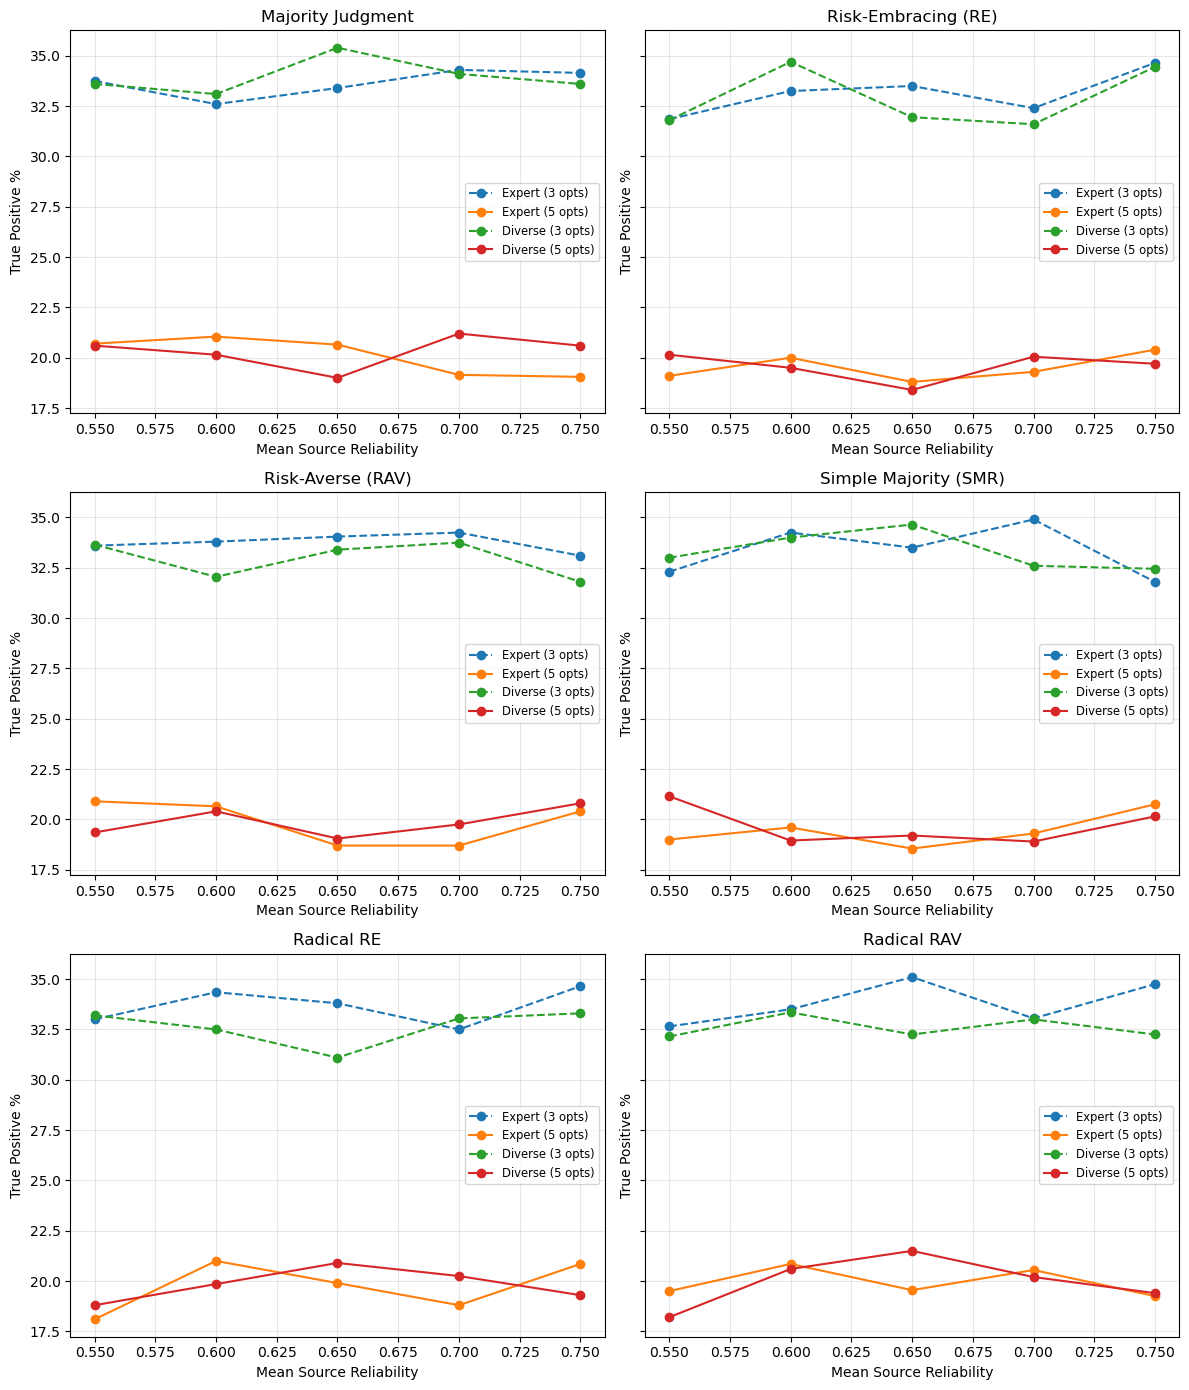

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum
from itertools import combinations

# ─────────────────────────────────────────────────────────────────────────────
# 1. GRADES & SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
class Grade(IntEnum):
    P = 0; F = 1; G = 2; VG = 3; E = 4

def majority_grade(grades: np.ndarray) -> int:
    """Returns the median grade (Majority Grade)."""
    sorted_g = np.sort(grades)[::-1]
    return sorted_g[(len(sorted_g) - 1) // 2]

def dominates(sorted_a: np.ndarray, sorted_b: np.ndarray) -> bool:
    """Strict Domination: a dominates b if all a_i >= b_i and at least one a_i > b_i."""
    return np.all(sorted_a >= sorted_b) and np.any(sorted_a > sorted_b)

def get_interval_scores(grades: np.ndarray, median: int):
    """
    Extracts grades strictly above and below the median.
    R_list: grades > median, sorted descending (R1, R2, ...)
    L_list: grades < median, sorted ascending (L1, L2, ...)
    """
    sorted_g = np.sort(grades)[::-1]
    above = sorted_g[sorted_g > median]
    below = np.sort(sorted_g[sorted_g < median])
    return above, below

def compare_mj(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """
    Strict Majority Judgment comparison.
    1. Compare Medians.
    2. Check Domination.
    3. Interval Expansion: Compare Right/Left tails stepwise.
    """
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    # 1. Compare Median
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # 2. Medians equal. Check Domination
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    # 3. Interval Expansion
    above_a, below_a = get_interval_scores(grades_a, med_a)
    above_b, below_b = get_interval_scores(grades_b, med_b)
    
    max_len = max(len(above_a), len(below_a), len(above_b), len(below_b))
    
    for k in range(1, max_len + 2):
        r1 = above_a[k-1] if k-1 < len(above_a) else -1
        r2 = above_b[k-1] if k-1 < len(above_b) else -1
        l1 = below_a[k-1] if k-1 < len(below_a) else -1
        l2 = below_b[k-1] if k-1 < len(below_b) else -1
        
        # 2.1 Dominant Option Wins
        cond_2_wins = (l1 <= l2 and r1 < r2) or (l1 < l2 and r1 <= r2)
        if cond_2_wins: return 'B'
        cond_1_wins = (l2 <= l1 and r2 < r1) or (l2 < l1 and r2 <= r1)
        if cond_1_wins: return 'A'
        
        # 2.2 Concision Wins
        concision_1_wins = (l1 >= l2 and r1 < r2) or (l1 > l2 and r1 <= r2)
        if concision_1_wins: return 'A'
        concision_2_wins = (l2 >= l1 and r2 < r1) or (l2 > l1 and r2 <= r1)
        if concision_2_wins: return 'B'
        
    return 'TIE'

def compare_re(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Embracing: Compare Right grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Averse: Compare Left grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_re_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RE: Skips domination check. Compares right tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RAV: Skips domination check. Compares left tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def select_best(grades_matrix: np.ndarray, rule: str) -> int:
    n_options = grades_matrix.shape[1]
    if rule == 'SMR':
        votes = np.zeros(n_options, dtype=int)
        max_grades = np.max(grades_matrix, axis=0)
        for j in range(n_options):
            votes[j] = np.sum(grades_matrix[:, j] == max_grades[j])
        max_votes = np.max(votes)
        candidates = np.where(votes == max_votes)[0]
        return np.random.choice(candidates)
    else:
        best = 0
        for j in range(1, n_options):
            if rule == 'MJ':
                cmp = compare_mj(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE':
                cmp = compare_re(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV':
                cmp = compare_rav(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE_RAD':
                cmp = compare_re_radical(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV_RAD':
                cmp = compare_rav_radical(grades_matrix[:, best], grades_matrix[:, j])
            else:
                raise ValueError(f"Unknown rule: {rule}")
            if cmp == 'B':
                best = j
        return best

# ─────────────────────────────────────────────────────────────────────────────
# 2. DIVERSITY & TEAM GENERATION (Duijf-inspired)
# ─────────────────────────────────────────────────────────────────────────────
def compute_diversity(agent_source_map: list) -> float:
    """Mean pairwise Jaccard dissimilarity of source sets."""
    n = len(agent_source_map)
    if n < 2: return 0.0
    dissims = []
    for i, j in combinations(range(n), 2):
        set_i, set_j = set(agent_source_map[i]), set(agent_source_map[j])
        overlap = len(set_i & set_j)
        union = len(set_i | set_j)
        dissims.append(1 - overlap / union if union > 0 else 0.0)
    return np.mean(dissims)

def generate_teams(n_agents: int, k: int, n_sources: int, team_type: str, rng: np.random.Generator):
    """
    team_type: 'expert' (high reliability, high overlap) | 'diverse' (low overlap, mixed reliability)
    """
    source_reliabilities = rng.uniform(0.55, 0.75, size=n_sources)
    
    if team_type == 'expert':
        top_sources = np.argsort(source_reliabilities)[-k:]
        agent_source_map = [top_sources.copy() for _ in range(n_agents)]
    elif team_type == 'diverse':
        agent_source_map = []
        available = np.arange(n_sources)
        for _ in range(n_agents):
            best_combo = None
            min_overlap = np.inf
            for combo in combinations(available, k):
                combo_set = set(combo)
                overlap = sum(len(combo_set & set(agent_source_map[a])) for a in range(len(agent_source_map)))
                if overlap < min_overlap:
                    min_overlap = overlap
                    best_combo = combo
            agent_source_map.append(np.array(best_combo))
            available = np.setdiff1d(available, best_combo)
            if len(available) < k:
                agent_source_map[-1] = rng.choice(n_sources, size=k, replace=True)
    else:
        agent_source_map = [rng.choice(n_sources, size=k, replace=False) for _ in range(n_agents)]
        
    return agent_source_map, source_reliabilities

# ─────────────────────────────────────────────────────────────────────────────
# 3. EVIDENCE GENERATION & DELIBERATION
# ─────────────────────────────────────────────────────────────────────────────
def generate_evidence(agent_source_map, source_reliabilities, true_grades, rng):
    """Agents aggregate noisy evidence from their sources per option."""
    n_agents = len(agent_source_map)
    n_options = len(true_grades)
    grades_matrix = np.zeros((n_agents, n_options), dtype=int)
    
    for i, sources in enumerate(agent_source_map):
        for j in range(n_options):
            source_grades = []
            for s in sources:
                if rng.random() < source_reliabilities[s]:
                    source_grades.append(true_grades[j])
                else:
                    source_grades.append(rng.integers(0, 5))
            grades_matrix[i, j] = np.bincount(source_grades, minlength=5).argmax()
    return grades_matrix

def deliberate_opinion_based(grades_matrix, rng):
    """Simple opinion-based sharing: each agent updates grade by majority of own + all others'."""
    n_agents, n_options = grades_matrix.shape
    updated = grades_matrix.copy()
    for i in range(n_agents):
        for j in range(n_options):
            all_grades = np.concatenate([grades_matrix[:, j], [grades_matrix[i, j]]])
            updated[i, j] = np.bincount(all_grades, minlength=5).argmax()
    return updated

# ─────────────────────────────────────────────────────────────────────────────
# 4. SIMULATION & SWEEP
# ─────────────────────────────────────────────────────────────────────────────
def simulate_round(n_agents: int, n_options: int, k: int, n_sources: int, 
                   source_reliability_mean: float, team_type: str, rule: str,
                   n_deliberation_rounds: int = 0, seed: int = None) -> dict:
    rng = np.random.default_rng(seed)
    true_grades = np.full(n_options, Grade.G, dtype=int)
    true_grades[np.random.randint(0, n_options)] = Grade.E
    
    agent_source_map, source_reliabilities = generate_teams(
        n_agents, k, n_sources, team_type, rng
    )
    source_reliabilities = source_reliabilities * (source_reliability_mean / np.mean(source_reliabilities))
    source_reliabilities = np.clip(source_reliabilities, 0.5, 0.95)
    
    grades_matrix = generate_evidence(agent_source_map, source_reliabilities, true_grades, rng)
    
    for _ in range(n_deliberation_rounds):
        grades_matrix = deliberate_opinion_based(grades_matrix, rng)
        
    selected = select_best(grades_matrix, rule)
    diversity = compute_diversity(agent_source_map)
    
    return {
        'selected': selected,
        'diversity': diversity,
        'avg_source_reliability': np.mean(source_reliabilities)
    }

def run_sweep(n_rounds: int = 2000, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    rules = ['MJ', 'RE', 'RAV', 'SMR', 'RE_RAD', 'RAV_RAD']
    team_types = ['expert', 'diverse']
    reliability_means = np.arange(0.55, 0.76, 0.05)
    n_options_list = [3, 5]
    
    records = []
    for rule in rules:
        for team in team_types:
            for n_opt in n_options_list:
                for rel_mean in reliability_means:
                    tp = 0
                    diversities = []
                    for _ in range(n_rounds):
                        truth_idx = np.random.randint(0, n_opt)
                        res = simulate_round(
                            n_agents=9, n_options=n_opt, k=5, n_sources=17,
                            source_reliability_mean=rel_mean, team_type=team,
                            rule=rule, n_deliberation_rounds=1, seed=None
                        )
                        if res['selected'] == truth_idx: tp += 1
                        diversities.append(res['diversity'])
                        
                    records.append({
                        'Rule': rule,
                        'Team': team,
                        'Options': n_opt,
                        'Reliability_Mean': rel_mean,
                        'TP%': tp / n_rounds * 100,
                        'Avg_Diversity': np.mean(diversities)
                    })
    return pd.DataFrame(records)

# ─────────────────────────────────────────────────────────────────────────────
# 5. VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
def plot_tradeoff_grid(df: pd.DataFrame):
    # 3x2 grid for 6 rules
    fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharey=True)
    rules = ['MJ', 'RE', 'RAV', 'SMR', 'RE_RAD', 'RAV_RAD']
    titles = ['Majority Judgment', 'Risk-Embracing (RE)', 'Risk-Averse (RAV)', 
              'Simple Majority (SMR)', 'Radical RE', 'Radical RAV']
    
    for ax, rule, title in zip(axes.ravel(), rules, titles):
        rule_df = df[df['Rule'] == rule]
        for team in ['expert', 'diverse']:
            subset = rule_df[rule_df['Team'] == team]
            # Plot separate lines for 3 and 5 options
            for n_opt in [3, 5]:
                opt_subset = subset[subset['Options'] == n_opt]
                linestyle = '--' if n_opt == 3 else '-'
                label = f'{team.capitalize()} (3 opts)' if n_opt == 3 else f'{team.capitalize()} (5 opts)'
                ax.plot(opt_subset['Reliability_Mean'], opt_subset['TP%'], 
                        marker='o', linestyle=linestyle, label=label)
        ax.set_title(title)
        ax.set_xlabel('Mean Source Reliability')
        ax.set_ylabel('True Positive %')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        
    axes[-1, 0].set_ylabel('True Positive %')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Running diversity-expertise sweep with 6 rules and 2 option counts...")
    results_df = run_sweep(n_rounds=2000)
    print("Sweep complete. Generating trade-off curves...\n")
    plot_tradeoff_grid(results_df)


### Key Findings: Deliberation & Problem Difficulty

1.  **The "5-Option Collapse":** The model performs well for **3 options** (~33–35% accuracy, beating the 33.3% random baseline) but collapses to **chance levels** (~20%) for **5 options**.
    *   *Cause:* Simple majority-based deliberation washes out high-grade signals (`E`), causing all options to converge on a mediocre `G` grade, which removes the signal needed for advanced rules like MJ or Radical RAV to distinguish the truth.

2.  **Expertise vs. Diversity (3 Options):** In the solvable 3-option setting, **Expert teams** often outperform Diverse teams, particularly for **Radical rules** (RE_RAD and RAV_RAD).
    *   *Takeaway:* When the problem is tractable, **quality** (access to reliable sources) outweighs **independence**. Diverse teams suffer from noisy signals that deliberation fails to correct.

3.  **Rule Performance:**
    *   **Radical Rules** (RE_RAD, RAV_RAD) show a slight edge over standard **MJ** in the 3-option setting, suggesting that aggressive tie-breaking on tail grades can help when high-quality sources are available.
    *   **SMR** is surprisingly competitive for 3 options, though it remains vulnerable in 5-option settings.

4.  **Conclusion:** Deliberation is a "double-edged sword." It helps diverse groups in low-reliability/noisy environments but can destroy signal in high-choice (5-option) settings by forcing premature consensus. Future work should explore less aggressive deliberation mechanisms (e.g., weighted averaging) to preserve truth-tracking in complex scenarios.
